In [ ]:
import pandas as pd
df = pd.read_csv('Sentimen_Cleaned(2).csv')
df.head()

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review,Sentimen_Biner
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"['untuk', 'servernya', 'full', 'dan', 'error',...","['servernya', 'full', 'error', 'jadi', 'susah'...","['servernya', 'full', 'error', 'jadi', 'susah'...",servernya full error jadi susah kerja,-1
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"['sudah', 'baik', 'untuk', 'tahun', 'ini', 'na...","['baik', 'tahun', 'lebih', 'baik', 'laksanakan...","['baik', 'tahun', 'lebih', 'baik', 'laksana', ...",baik tahun lebih baik laksana langsung terima ...,1
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"['tolong', 'perbaiki', 'website', 'ppkmb', 'se...","['perbaiki', 'website', 'ppkmb', 'lebih', 'mud...","['baik', 'website', 'ppkmb', 'lebih', 'mudah',...",baik website ppkmb lebih mudah cepat akses,1
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"['kegiatan', 'pkkmb', 'tahun', 'ini', 'menurut...","['kegiatan', 'pkkmb', 'tahun', 'berjalan', 'ba...","['giat', 'pkkmb', 'tahun', 'jalan', 'baik', 'b...",giat pkkmb tahun jalan baik beri banyak inform...,1
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"['semoga', 'lebih', 'baik']","['semoga', 'lebih', 'baik']","['moga', 'lebih', 'baik']",moga lebih baik,1


In [ ]:
df = df[['Kritik dan saran', 'Sentimen']]
df.columns = ['text', 'label']
df.head()

,text,label
0,Untuk servernya full dan error jadi agak susah...,negatif
1,Sudah baik untuk tahun ini namun akan lebih ba...,positif
2,Tolong perbaiki website PPKMB sehingga lebih m...,positif
3,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif
4,Semoga lebih baik,positif


In [ ]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8025 entries, 0 to 8024
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8025 non-null   object
 1   label   8025 non-null   object
dtypes: object(2)
memory usage: 125.5+ KB


,count
label,
positif,4126
netral,2703
negatif,1196


In [ ]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+', '', text)     # hapus mention
    text = re.sub(r'#\w+', '', text)     # hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.head()

,text,label,clean_text
0,Untuk servernya full dan error jadi agak susah...,negatif,untuk servernya full dan error jadi agak susah...
1,Sudah baik untuk tahun ini namun akan lebih ba...,positif,sudah baik untuk tahun ini namun akan lebih ba...
2,Tolong perbaiki website PPKMB sehingga lebih m...,positif,tolong perbaiki website ppkmb sehingga lebih m...
3,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,kegiatan pkkmb tahun ini menurut saya sudah be...
4,Semoga lebih baik,positif,semoga lebih baik


In [ ]:
!pip install Sastrawi

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [ ]:
label_map = {
    'negatif': 0,
    'netral': 1,
    'positif': 2
}

df['label'] = df['label'].map(label_map)
df['label'].value_counts()

,count
label,
2,4126
1,2703
0,1196


In [ ]:
df['label'].value_counts(normalize=True)

,proportion
label,
2,0.514143
1,0.336822
0,0.149034


In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "bgt": "banget"
}

def normalize_slang(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

df['clean_text'] = df['clean_text'].apply(normalize_slang)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [ ]:
max_vocab = 10000   # jumlah kata maksimum
max_len = 100       # panjang maksimal kalimat

In [ ]:
vectorizer = TextVectorization(
    max_tokens=max_vocab,
    output_mode='int',
    output_sequence_length=max_len,
    ngrams=2
)

In [ ]:
vectorizer.adapt(X_train)

In [ ]:
sample = ["servernya full error"]
vectorizer(sample)

<tf.Tensor: shape=(1, 100), dtype=int64, numpy=
array([[ 521, 1568,  162,    1,    1,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0]])>

In [ ]:
X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)

In [ ]:
X_train_vec.shape

TensorShape([6420, 100])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=100),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 129ms/step - accuracy: 0.7064 - loss: 0.6579 - val_accuracy: 0.8361 - val_loss: 0.4159
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - accuracy: 0.8361 - loss: 0.4185 - val_accuracy: 0.8679 - val_loss: 0.3353
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.9393 - loss: 0.1888 - val_accuracy: 0.8891 - val_loss: 0.3018
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.9646 - loss: 0.1113 - val_accuracy: 0.8847 - val_loss: 0.3603
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.9794 - loss: 0.0732 - val_accuracy: 0.8698 - val_loss: 0.4090
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.9824 - loss: 0.0565 - val_accuracy: 0.8872 - val_loss: 0.4434
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.9858 - loss: 0.0480 - val_accuracy: 0.8841 - val_loss: 0.4839
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.9897 - loss: 0

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.8947 - val_loss: 0.5724
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.8935 - val_loss: 0.6110
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.9933 - loss: 0.0257 - val_accuracy: 0.8822 - val_loss: 0.5043
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.8748 - val_loss: 0.6642
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.9930 - loss: 0.0237 - val_accuracy: 0.8903 - val_loss: 0.5887
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.8922 - val_loss: 0.5636


In [ ]:
loss, acc = model.evaluate(X_val_vec, y_val)
print("Accuracy:", acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8822 - loss: 0.5043
Accuracy: 0.8822429776191711


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(X_val_vec)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred)
print(cm)

51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step
[[218  20   1]
 [ 18 431  92]
 [  1  57 767]]


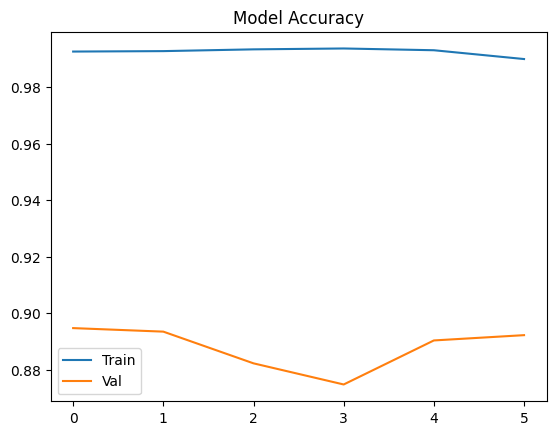

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Val'])
plt.show()

In [ ]:
model.save("final_model.keras")

In [ ]:
def predict_sentiment(text):
    text = vectorizer([text])
    pred = model.predict(text)
    label = np.argmax(pred)

    mapping = {0: "negatif", 1: "netral", 2: "positif"}
    return mapping[label]

print(predict_sentiment("acaranya seru"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
positif
